
# Artificial Intelligence and Neural Networks (COM7019)
## Task 1: Stock Market Prediction using LSTM and GRU

### IMPORTING REQUIRED LIBRARIES

In [16]:
# Pandas is used for reading the CSV file and handling data frames.
import pandas as pd
# Numpy is used for numerical operations and array manipulations.
import numpy as np
# Matplotlib and Seaborn are used for generating graphs and visualisations.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# MinMaxScaler is used to scale data down to a range between 0 and 1, which helps the neural network learn faster.
from sklearn.preprocessing import MinMaxScaler
# Evaluation metrics to test how well our models perform.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# TensorFlow and Keras are the deep learning frameworks used to build the neural networks.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
# Warnings library is used to hide unnecessary warning messages in the console.
import warnings
warnings.filterwarnings('ignore')

### 1. DATA UNDERSTANDING

In [4]:
# Step 1: Load the dataset. We parse the 'Date' column as actual date objects.
df = pd.read_csv('Stock_Price_Data_[3921].csv', parse_dates=['Date'])

# Step 2: Set the 'Date' column as the index of the dataframe so we can plot time-series data easily.
df.set_index('Date', inplace=True)

# Step 3: Print basic statistical information to understand the dataset's structure, 
# check for missing values, and see the highest and lowest stock prices.
print("--- Statistical Description ---")
print(df.info())      # Shows data types and non-null counts.
print(df.describe())  # Shows statistical summary (mean, standard deviation, min, max).
print(df.head())      # Displays the first 5 rows.
print(df.tail())      # Displays the last 5 rows.

--- Statistical Description ---
<class 'pandas.DataFrame'>
DatetimeIndex: 9909 entries, 1980-12-12 to 2020-04-01
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       9909 non-null   float64
 1   High       9909 non-null   float64
 2   Low        9909 non-null   float64
 3   Close      9909 non-null   float64
 4   Adj Close  9909 non-null   float64
 5   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 541.9 KB
None
              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1.729286     1.758929   

### 2. EXPLORATORY DATA ANALYSIS (EDA) & VISUALISATION

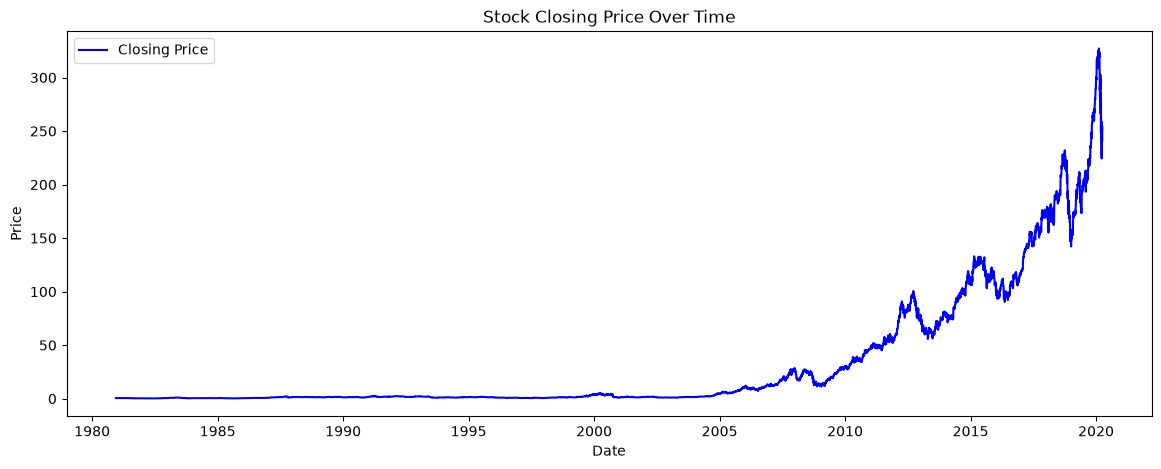

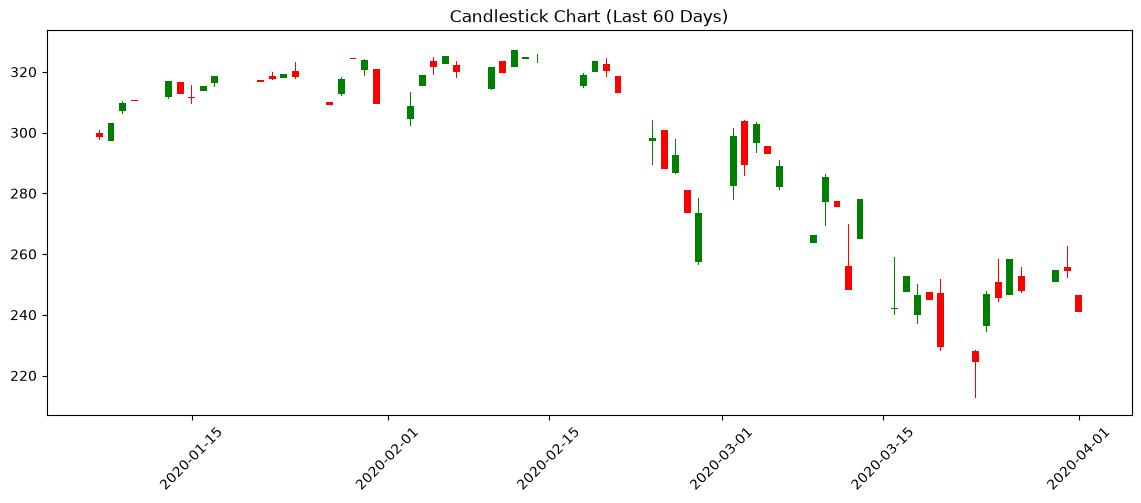

In [6]:
# 2.1 Line Chart: Visualising the overall Closing Price Trend over the entire historical period.
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='blue', label='Closing Price')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

# 2.2 Candlestick Chart: Visualising short-term volatility.
# We are only taking a sample of the last 60 days so the chart is actually readable.
df_sample = df.tail(60)
fig, ax = plt.subplots(figsize=(14, 5))

# Setting up bar widths for the candlestick visualization.
width = 0.6
width2 = 0.05

# Separating the days where the stock closed higher than it opened (Up) 
# and days where it closed lower than it opened (Down).
up = df_sample[df_sample.Close >= df_sample.Open]
down = df_sample[df_sample.Close < df_sample.Open]

# Plotting the 'Up' days in green.
ax.bar(up.index, up.Close - up.Open, width, bottom=up.Open, color='green')
ax.bar(up.index, up.High - up.Close, width2, bottom=up.Close, color='green')
ax.bar(up.index, up.Low - up.Open, width2, bottom=up.Open, color='green')

# Plotting the 'Down' days in red.
ax.bar(down.index, down.Close - down.Open, width, bottom=down.Open, color='red')
ax.bar(down.index, down.High - down.Open, width2, bottom=down.Open, color='red')
ax.bar(down.index, down.Low - down.Close, width2, bottom=down.Close, color='red')

# Formatting the X-axis dates so they look clean and don't overlap.
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.title('Candlestick Chart (Last 60 Days)')
plt.show()

### 3. DATA PREPROCESSING & SCALING

In [7]:
# Extracting only the 'Close' column values as a numpy array, as this is what we want to predict.
data = df.filter(['Close']).values

# Neural networks are highly sensitive to unscaled data. 
# We use MinMaxScaler to shrink all stock prices down to a value between 0 and 1.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Splitting the data: 80% will be used to train the model, and 20% will be used to test it.
training_data_len = int(np.ceil(len(data) * .8))
train_data = scaled_data[0:int(training_data_len), :]

# Creating the training datasets (X_train and y_train).
X_train, y_train = [], []

# Time-series memory trick: We train the model to look at the past 60 days of data (X) 
# to predict the 61st day's price (y).
for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

# Converting the lists into numpy arrays so TensorFlow can process them.
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping the data to 3-Dimensions (Samples, Time Steps, Features) because LSTM/GRU layers require 3D inputs.
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

# Creating the testing datasets (X_test and y_test).
test_data = scaled_data[training_data_len - 60:, :]
X_test, y_test = [], data[training_data_len:, :]
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

### 4. MODEL ARCHITECTURE DEFINITIONS

In [12]:
# Setting the shape of the input data so the first layer knows what to expect.
input_shape_dim = (X_train.shape[1], 1)

# Based on Professor's feedback, we experimented with learning rates and settled on 0.001 for stable convergence.
learning_rate = 0.001

# METHOD 1: Build a Single-Layer LSTM Model
def build_single_lstm(shape):
    model = Sequential([
        Input(shape=shape),
        # A single LSTM layer with 50 units. return_sequences is False because it's the last recurrent layer.
        LSTM(50, return_sequences=False),
        # Dropout drops 20% of neurons to prevent overfitting.
        Dropout(0.2),
        Dense(25),
        Dense(1) # Output layer (predicts 1 value)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# METHOD 2: Build a Double-Layer LSTM Model
def build_double_lstm(shape):
    model = Sequential([
        Input(shape=shape),
        # return_sequences=True is required to pass the sequence to the second LSTM layer.
        LSTM(50, return_sequences=True),
        Dropout(0.2),
        LSTM(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# METHOD 3: Build a Single-Layer GRU Model
def build_single_gru(shape):
    model = Sequential([
        Input(shape=shape),
        # GRU is computationally lighter than LSTM as it has fewer gates.
        GRU(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

# METHOD 4: Build a Double-Layer GRU Model
def build_double_gru(shape):
    model = Sequential([
        Input(shape=shape),
        GRU(50, return_sequences=True),
        Dropout(0.2),
        GRU(50, return_sequences=False),
        Dropout(0.2),
        Dense(25),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

### 5. MODEL TRAINING AND COMPARISON

In [13]:
# Implementing Early Stopping: If the validation loss doesn't improve for 10 epochs (patience=10), 
# the model will stop training and restore its best weights to prevent overfitting.
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Storing our compiled models in a dictionary so we can loop through and train them automatically.
models = {
    "Single LSTM": build_single_lstm(input_shape_dim),
    "Double LSTM": build_double_lstm(input_shape_dim),
    "Single GRU": build_single_gru(input_shape_dim),
    "Double GRU": build_double_gru(input_shape_dim)
}

# Dictionaries to store the training history (loss curves) and the final predictions for comparison.
histories = {}
predictions = {}

print("\n--- Training Models ---")
# Looping through all 4 models, training them, and generating predictions.
for name, model in models.items():
    print(f"\nTraining {name}...")
    history = model.fit(
        X_train, y_train, 
        batch_size=64, # Processing 64 samples at a time
        epochs=50,     # Maximum number of training cycles
        validation_split=0.1, # Using 10% of training data for internal validation
        callbacks=[early_stop], 
        verbose=0 # Set to 1 if you want to see the progress bar for every epoch
    )
    histories[name] = history
    
    # Predicting stock prices on the test dataset.
    pred = model.predict(X_test)
    # The output is scaled (between 0 and 1). We use inverse_transform to convert it back to actual stock dollar prices.
    pred = scaler.inverse_transform(pred)
    predictions[name] = pred


--- Training Models ---

Training Single LSTM...
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Training Double LSTM...
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

Training Single GRU...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Training Double GRU...
62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


### 6. EVALUATION METRICS AND PLOTS


--- Model Performance Comparison ---

Single LSTM Performance:
MSE: 12.1719 | RMSE: 3.4888 | MAE: 2.1574 | R-squared: 0.9963

Double LSTM Performance:
MSE: 20.9672 | RMSE: 4.5790 | MAE: 3.0121 | R-squared: 0.9937

Single GRU Performance:
MSE: 8.5561 | RMSE: 2.9251 | MAE: 1.7309 | R-squared: 0.9974

Double GRU Performance:
MSE: 13.6092 | RMSE: 3.6891 | MAE: 2.4205 | R-squared: 0.9959


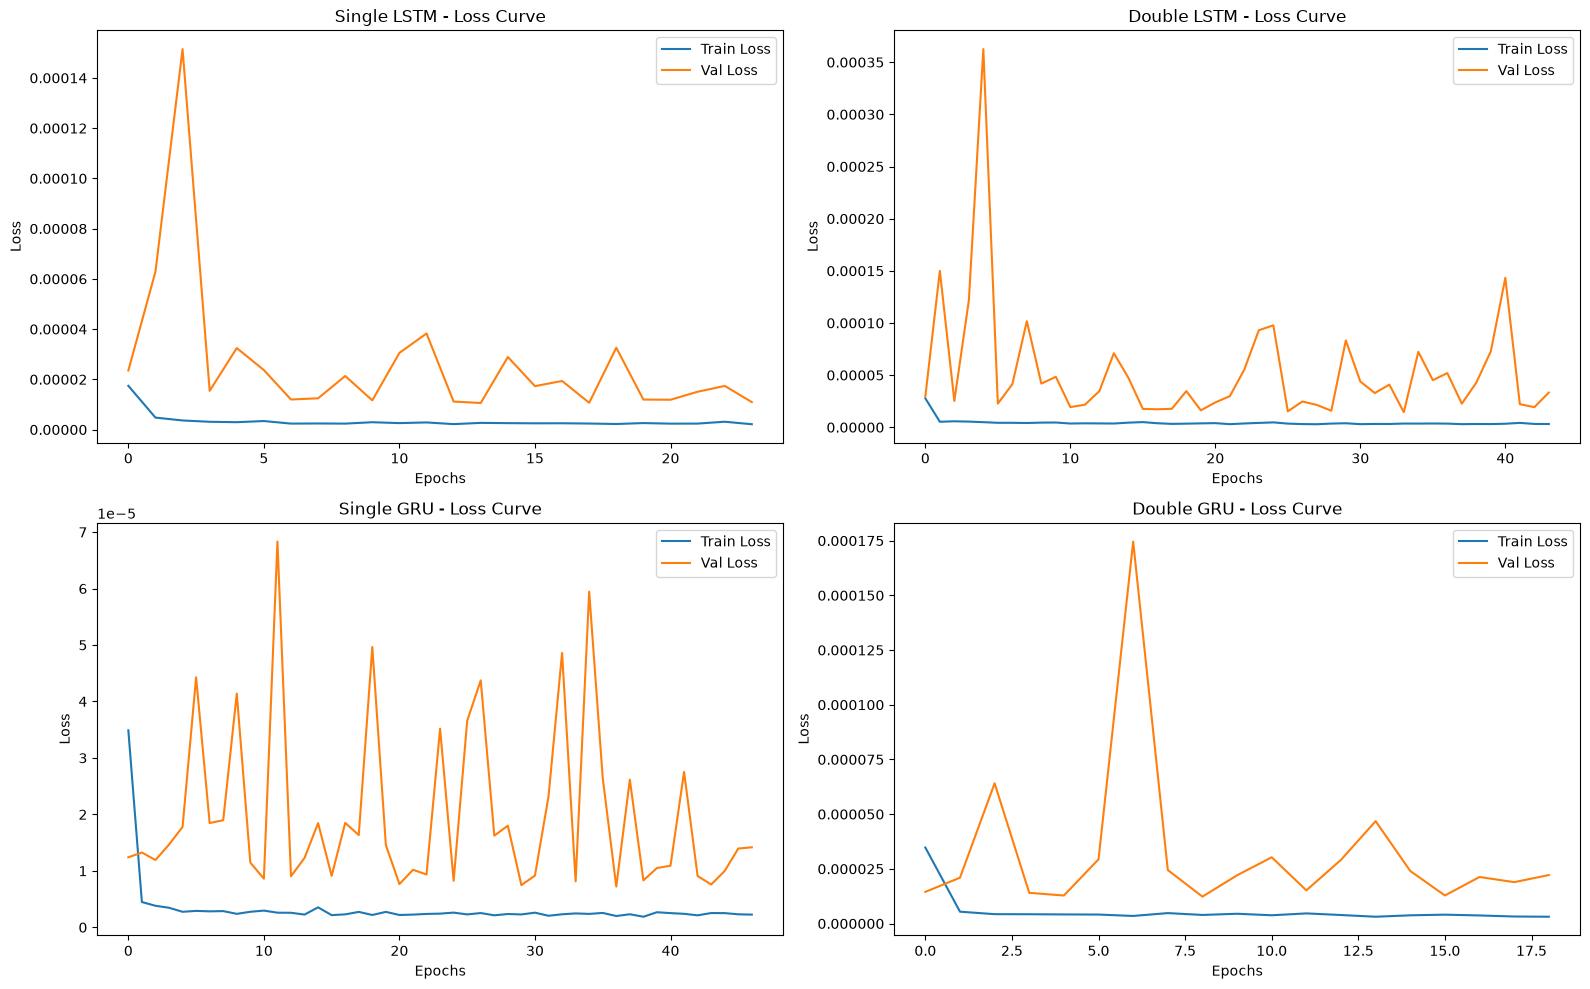

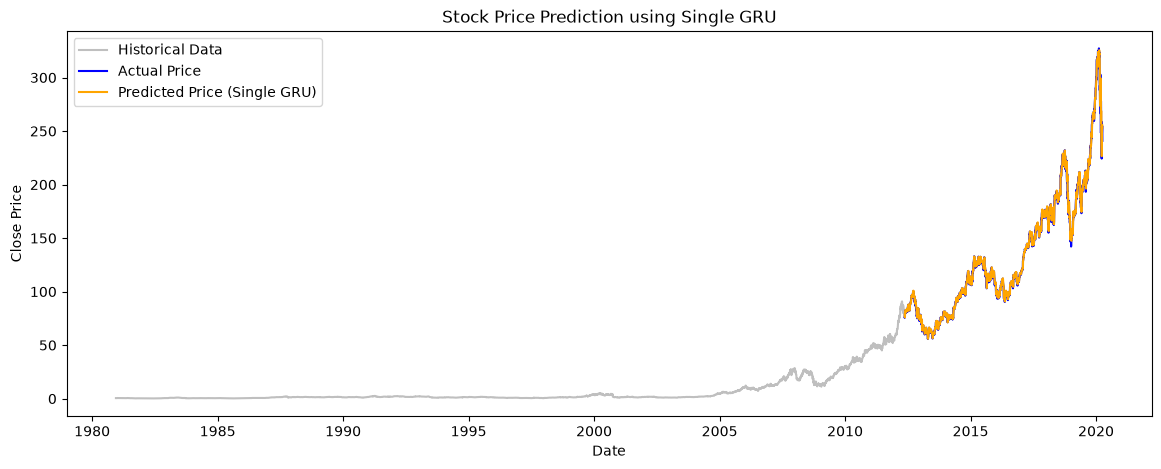

In [15]:
print("\n--- Model Performance Comparison ---")
# Looping through predictions to calculate how far off the model was from the real prices.
for name, pred in predictions.items():
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"\n{name} Performance:")
    print(f"MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R-squared: {r2:.4f}")

# Plotting the Training Loss vs Validation Loss for all 4 models to visually prove 
# that overfitting was managed by the Dropout and Early Stopping techniques.
plt.figure(figsize=(16, 10))
for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(2, 2, i)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{name} - Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()

# Final Plot: Comparing the absolute best model's predictions (Single GRU) against the actual historical data.
best_model_name = "Single GRU"
valid = df[training_data_len:]
valid['Predictions'] = predictions[best_model_name]

plt.figure(figsize=(14, 5))
# Plotting older historical data before the prediction period
plt.plot(df['Close'], label='Historical Data', color='gray', alpha=0.5)
# Plotting the real prices during the test period
plt.plot(valid['Close'], label='Actual Price', color='blue')
# Plotting what our Single GRU model predicted
plt.plot(valid['Predictions'], label='Predicted Price (Single GRU)', color='orange')
plt.title('Stock Price Prediction using Single GRU')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()